# Decision Tree Classifier: Housing Purchase Prediction

This notebook implements a complete, end-to-end machine learning workflow using a **Decision Tree Classifier** to predict whether an individual will purchase a house based on two features: **Age** and **Income**.

---

## Table of Contents
1. **Data Preparation**: Creation and structure of the synthetic housing dataset.
2. **Feature & Target Selection**: Defining predictor variables ($X$) and the target class ($y$).
3. **Model Configuration**: Initializing and training the `DecisionTreeClassifier` with specific parameters (Gini, max depth).
4. **Tree Visualization**: Plotting and interpreting the decision nodes, splits, and thresholds.
5. **Inference**: Making predictions on unseen data points.
6. **Model Evaluation**: Splitting the dataset, validating the performance, and generating a confusion matrix.

---

## Prerequisites & Setup
To run this notebook, you need the following standard Python libraries:
* **Pandas**: For data structures and data manipulation.
* **Scikit-learn**: For machine learning model building, splitting datasets, and evaluation metrics.
* **Matplotlib**: For rendering tree structures and the confusion matrix.

---

## Model & Logic Summary
* **Classifier**: `DecisionTreeClassifier` (using `criterion='gini'` and `max_depth=2` to avoid overfitting on our small dataset).
* **Core Split Criterion**: The tree first splits on the root node **`Age <= 30.5`** to segment prospective buyers.
* **Evaluation**: Uses a $80/20$ train-test split and evaluates accuracy via a visual **Confusion Matrix**.

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
data = {
    'Age': [22, 25, 28, 30, 31, 35, 40, 42, 45, 50, 55],
    'Income': [25000, 45000, 30000, 60000, 35000,
               50000, 70000, 65000, 40000, 80000, 55000],
    'Buy_House': ['No', 'No', 'No', 'No', 'Yes',
                  'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes']
}
df = pd.DataFrame(data)
print(df)

    Age  Income Buy_House
0    22   25000        No
1    25   45000        No
2    28   30000        No
3    30   60000        No
4    31   35000       Yes
5    35   50000       Yes
6    40   70000       Yes
7    42   65000       Yes
8    45   40000       Yes
9    50   80000       Yes
10   55   55000       Yes


In [ ]:
X = df[['Age','Income']]
y = df['Buy_House']

In [ ]:
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=2,
    random_state=42
)

model.fit(X, y)

DecisionTreeClassifier(max_depth=2, random_state=42)

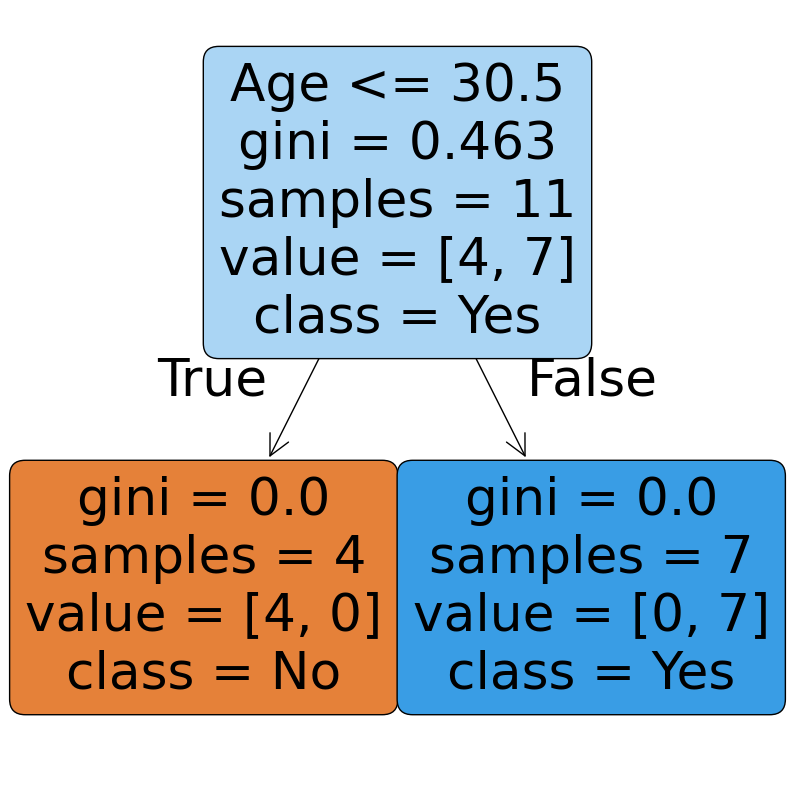

In [ ]:
plt.figure(figsize=(10,10))
tree.plot_tree(model,
               feature_names=['Age','Income'],
               class_names=['No','Yes'],
               filled=True,
               rounded=True)
plt.show()

In [ ]:
Age=35
Income=55000
new_person = [[35,55000]]
pred = model.predict(new_person)
print("Prediction:Will she buy the house? ",pred[0])

Prediction:Will she buy the house?  Yes


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
Age=25
Income=55000
n_person = [[25,55000]]
pred = model.predict(n_person)
print("Prediction:Will she buy the house? ",pred[0])

Prediction:Will she buy the house?  No


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


[[1 0]
 [0 2]]


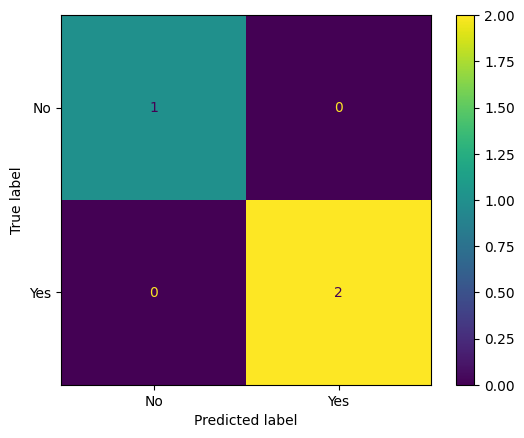

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Re-fit the model with the training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.show()